In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/sleep_mobile_stress_dataset_15000.csv


# Problem Statement

Excessive smartphone usage, especially before sleep, can negatively affect sleep quality, increase mental fatigue, and raise stress levels. Understanding how digital behavior influences well-being is important for developing effective wellness strategies.

**Objectives**

- Analyze relationships between screen time, sleep patterns, and stress.

- Build machine learning models to predict stress levels.

- Compare model performance.

- Use SHAP to identify key factors influencing stress.

- Discover behavioral patterns through clustering.

#  Imports

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.cluster import KMeans

#  Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/sleep_mobile_stress_dataset_15000.csv')

# Basic understanding dataset

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [5]:
df.dtypes

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

In [6]:
df.columns


Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

In [7]:
df.describe()


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.isnull().sum()


user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

#  Feature Engineering

In [10]:
df['night_screen_ratio'] = df['phone_usage_before_sleep_minutes'] / (df['daily_screen_time_hours']*60 + 1e-6)
# Sleep efficiency
df['sleep_efficiency'] = df['sleep_quality_score'] / (df['sleep_duration_hours'] + 1e-6)
# Notification stress index
df['notification_stress_index'] = df['notifications_received_per_day'] * df['daily_screen_time_hours']
# Multi-class stress label: Low, Medium, High
df['stress_class'] = pd.cut(df['stress_level'], bins=[0,4,7,10], labels=['Low','Medium','High'])

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['gender','occupation'], drop_first=True)

# Features and target
X = df_encoded.drop(columns=['user_id','stress_level','stress_class'])
y = df_encoded['stress_class']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#  Exploratory Data Analysis with Plotly

In [11]:
# Age distribution
fig = px.histogram(df, x='age', nbins=20, title='Age Distribution of Users')
fig.show()

# Screen time vs sleep duration
fig = px.scatter(df, x='daily_screen_time_hours', y='sleep_duration_hours', color='gender',
                 hover_data=['stress_level','occupation'], title='Screen Time vs Sleep Duration')
fig.show()

# Sleep quality vs stress level
fig = px.scatter(df, x='sleep_quality_score', y='stress_level', color='stress_class',
                 title='Sleep Quality vs Stress Level')
fig.show()

# Heatmap correlation
corr = df.select_dtypes(include=['float64','int64']).corr()
fig = px.imshow(corr, text_auto=True, aspect="auto", title="Correlation Heatmap")
fig.show()

#  Multiple Model Training & Comparison

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append([name, acc, f1])
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# Compare models
results_df = pd.DataFrame(results, columns=['Model','Accuracy','Macro F1'])
fig = px.bar(results_df, x='Model', y=['Accuracy','Macro F1'], barmode='group', title='Model Comparison')
fig.show()

    


Model: Logistic Regression
Accuracy: 0.8953, Macro F1: 0.8736
              precision    recall  f1-score   support

        High       0.95      0.95      0.95      1615
         Low       0.85      0.86      0.86       547
      Medium       0.81      0.81      0.81       838

    accuracy                           0.90      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.90      0.90      0.90      3000

Model: Random Forest
Accuracy: 0.8907, Macro F1: 0.8672
              precision    recall  f1-score   support

        High       0.95      0.95      0.95      1615
         Low       0.85      0.84      0.85       547
      Medium       0.80      0.81      0.80       838

    accuracy                           0.89      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.89      0.89      0.89      3000

Model: XGBoost
Accuracy: 0.8817, Macro F1: 0.8567
              precision    recall  f1-score   support

        High   

#  SHAP on Best Model

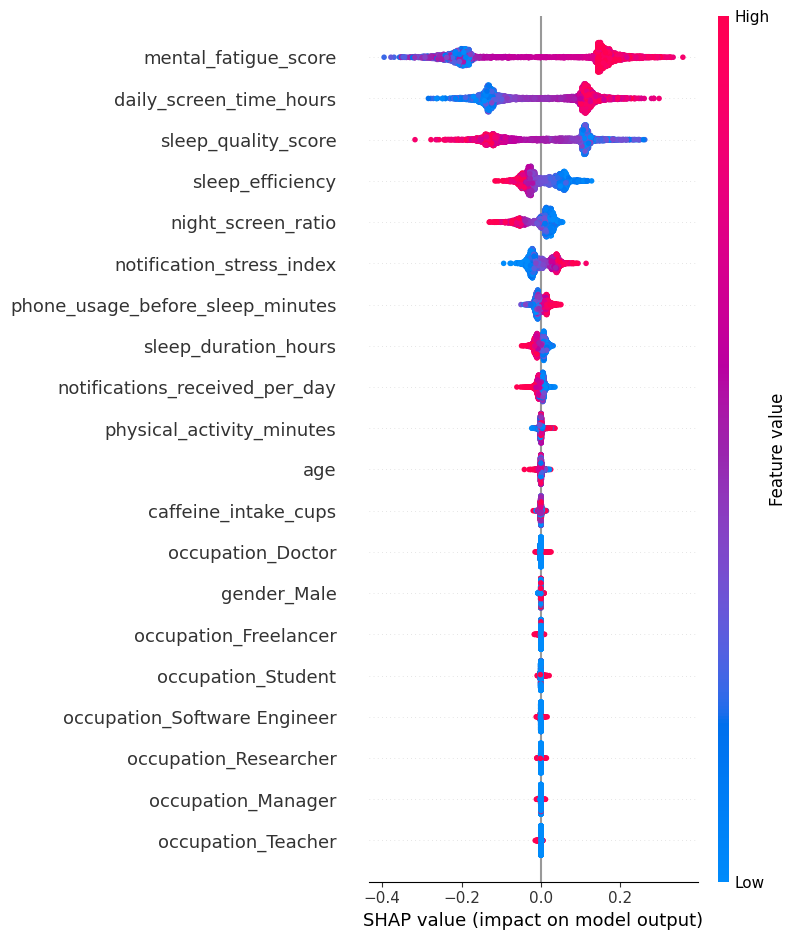

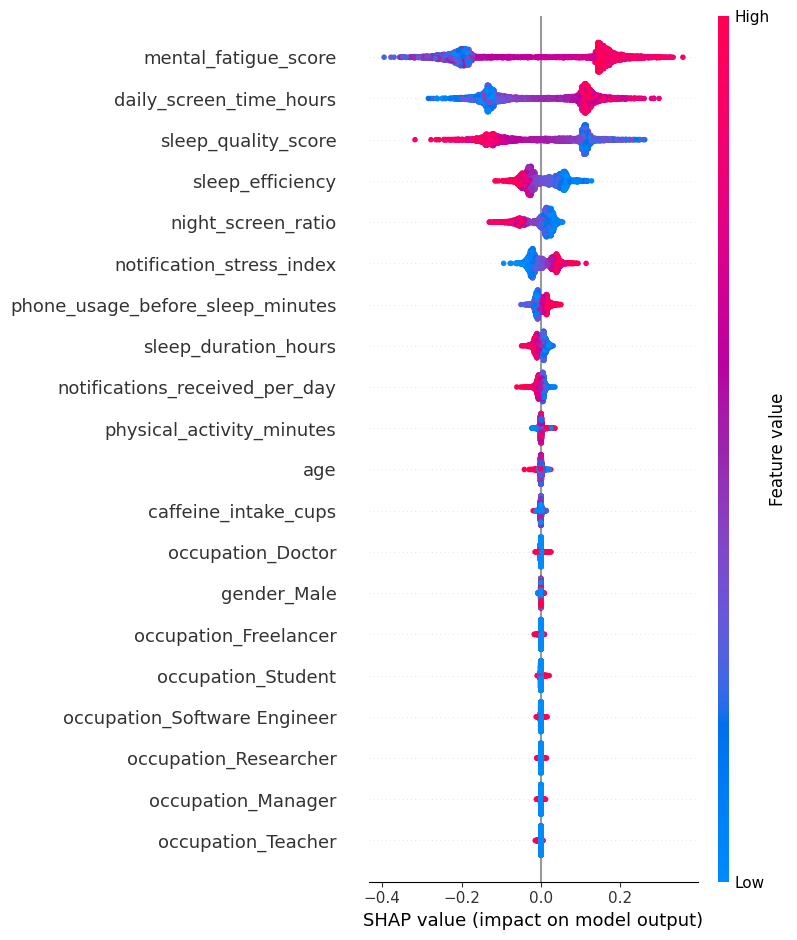

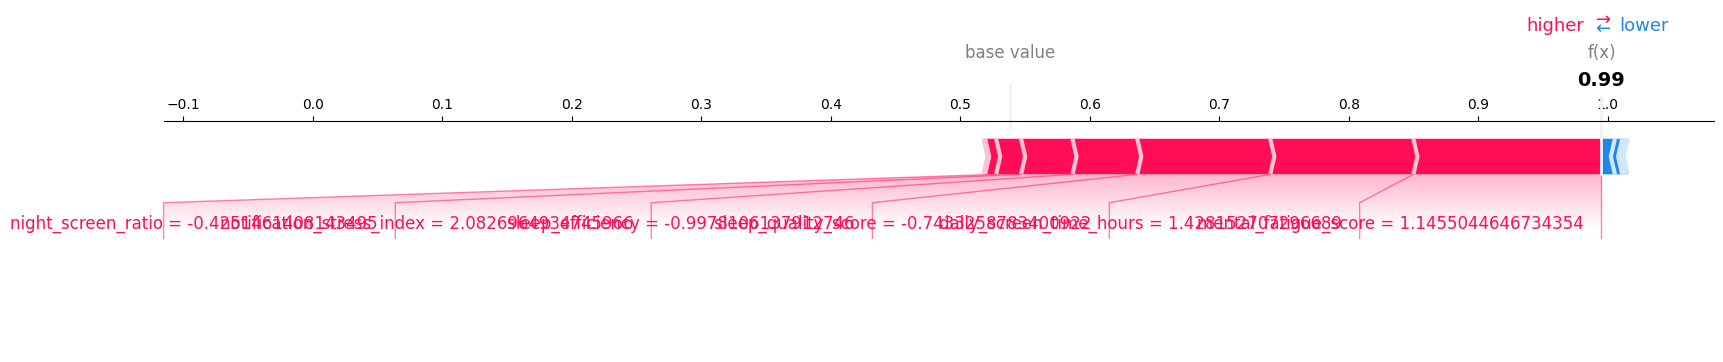

In [13]:



best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)


X_test_df = pd.DataFrame(X_test, columns=X.columns)


explainer = shap.TreeExplainer(best_model)

# This returns an Explanation object
shap_values = explainer(X_test_df)



# Bar plot (global importance)
shap.summary_plot(shap_values.values[:,:,0], X_test_df)

# Beeswarm plot
shap.summary_plot(shap_values.values[:,:,0], X_test_df)


shap.initjs()

instance_id = 0
class_id = 0   

shap.force_plot(
    shap_values.base_values[instance_id][class_id],
    shap_values.values[instance_id,:,class_id],
    X_test_df.iloc[instance_id],
    matplotlib=True
)

# Behavioral Clustering

In [14]:
cluster_features = df[['daily_screen_time_hours','sleep_duration_hours','stress_level','mental_fatigue_score','physical_activity_minutes']]
cluster_scaled = scaler.fit_transform(cluster_features)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)
df['behavior_cluster'] = clusters

# Plot clusters interactively
fig = px.scatter_3d(df, x='daily_screen_time_hours', y='sleep_duration_hours', z='stress_level',
                    color='behavior_cluster', hover_data=['age','gender','occupation'],
                    title='3D Behavioral Clustering of Users')
fig.show()